In [92]:
!pip install hydrofunctions

In [93]:
# Import packages
import os
import urllib
import requests
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import earthpy as et
import hydrofunctions as hf
import warnings
from hydrofunctions.exceptions import HydroUserWarning

# Date time conversion registration
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Get the data & set working director
data = et.data.get_data('colorado-flood')
os.chdir(os.path.join(et.io.HOME, 'earth-analytics'))

# Prettier plotting with seaborn
sns.set(font_scale=1.5, style="whitegrid")

In [94]:
hf.draw_map()

In [95]:
# Request data for all stations in Colorado
PR = hf.NWIS(stateCd='CO').get_data()

# Suppress the repetitive frequency warnings from hydrofunctions
warnings.filterwarnings("ignore", category=HydroUserWarning)
warnings.filterwarnings("ignore", message=".*frequency for one of the datasets.*")

Requesting data from https://waterservices.usgs.gov/nwis/dv/?...

It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible t

Requested data from https://waterservices.usgs.gov/nwis/dv/?format=json%2C1.1&stateCd=CO


It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible to determine the frequency for one of the datasets in this request. This dataset will be set to a frequency of 0 minutes
It is not possible t

Let's get the mean Daly Value whch is represented with 'dv'

In [96]:
# Define the site number and start and end dates that you are interested in
site = "06730500"
start = '1946-05-10'
end = '2018-08-29'

# Request data for that site and time period
longmont_resp = hf.get_nwis(site, 'dv', start, end)

# Unpack both the data frame AND the metadata dictionary
longmont_discharge, longmont_meta = hf.extract_nwis_df(longmont_resp)

longmont_discharge.head()

Requested data from https://waterservices.usgs.gov/nwis/dv/?format=json%2C1.1&sites=06730500&startDT=1946-05-10&endDT=2018-08-29


,USGS:06730500:00060:00003,USGS:06730500:00060:00003_qualifiers
datetimeUTC,,
1946-05-10 00:00:00+00:00,16.0,A
1946-05-11 00:00:00+00:00,19.0,A
1946-05-12 00:00:00+00:00,9.0,A
1946-05-13 00:00:00+00:00,3.0,A
1946-05-14 00:00:00+00:00,7.8,A


Let's get the Instantaneous Value whch is represented with 'iv'

In [97]:
# Rename columns
longmont_discharge.columns = ["discharge", "flag"]

# View first 5 rows
longmont_discharge.head()

,discharge,flag
datetimeUTC,,
1946-05-10 00:00:00+00:00,16.0,A
1946-05-11 00:00:00+00:00,19.0,A
1946-05-12 00:00:00+00:00,9.0,A
1946-05-13 00:00:00+00:00,3.0,A
1946-05-14 00:00:00+00:00,7.8,A


In [98]:
# View last 5 rows
longmont_discharge.tail()

,discharge,flag
datetimeUTC,,
2018-08-25 00:00:00+00:00,9.86,A
2018-08-26 00:00:00+00:00,7.02,A
2018-08-27 00:00:00+00:00,4.05,A
2018-08-28 00:00:00+00:00,2.67,A
2018-08-29 00:00:00+00:00,3.36,A


In [99]:
longmont_discharge.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 26410 entries, 1946-05-10 00:00:00+00:00 to 2018-08-29 00:00:00+00:00
Freq: 24h
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   discharge  17082 non-null  float64
 1   flag       26410 non-null  str    
dtypes: float64(1), str(1)
memory usage: 728.4 KB


In [100]:
days_with_no_info=longmont_discharge.isnull().sum()
print(days_with_no_info)

discharge    9328
flag            0
dtype: int64


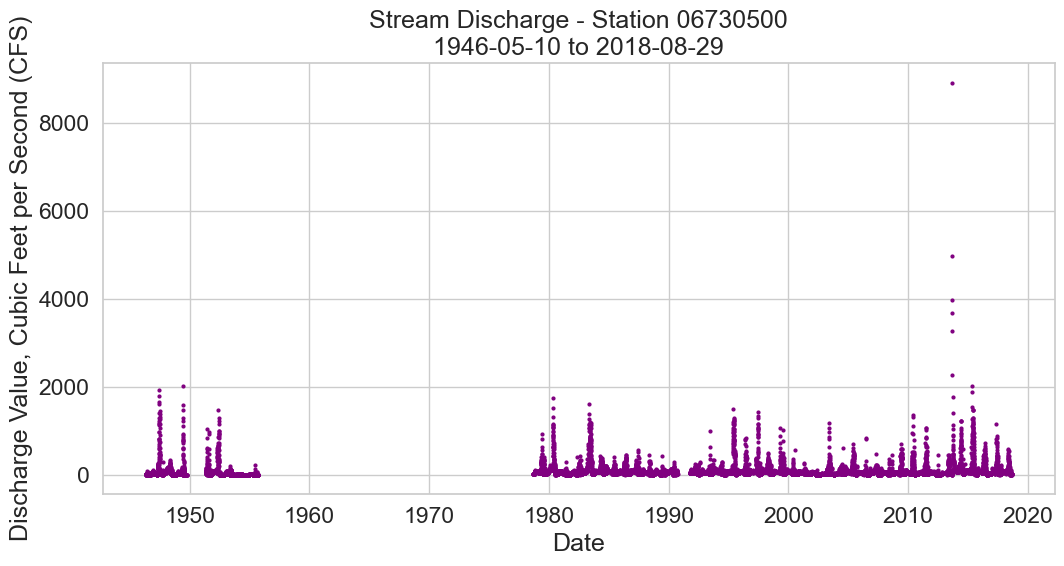

In [101]:
%matplotlib inline
# Initialize the plotting canvas
fig, ax = plt.subplots(figsize=(11, 6))


ax.scatter(x=longmont_discharge.index,
           y=longmont_discharge["discharge"],
           marker="o",
           s=4,
           color="purple")

# Set the labels and dynamic title formatting
ax.set(xlabel="Date", 
       ylabel="Discharge Value, Cubic Feet per Second (CFS)",
       title="Stream Discharge - Station {}\n{} to {}".format(site, start, end))

# Clean up layout padding and display
fig.tight_layout()
plt.show()

In [102]:
# add a year column to your longmont discharge data
longmont_discharge["year"] = longmont_discharge.index.year

# Calculate annual max by resampling
longmont_discharge_annual_max = longmont_discharge.resample('YS').max()
longmont_discharge_annual_max.head()

,discharge,flag,year
datetimeUTC,,,
1946-01-01 00:00:00+00:00,99.0,A,1946
1947-01-01 00:00:00+00:00,1930.0,A,1947
1948-01-01 00:00:00+00:00,339.0,A,1948
1949-01-01 00:00:00+00:00,2010.0,hf.missing,1949
1950-01-01 00:00:00+00:00,NaN,hf.missing,1950


In [103]:
longmont_discharge_annual_max.isnull().sum()

discharge    23
flag          0
year          0
dtype: int64

In [104]:
# download usgs annual max data from figshare
url = "https://nwis.waterdata.usgs.gov/nwis/peak?site_no=06730500&agency_cd=USGS&format=rdb"
download_path = os.path.join("data", "colorado-flood", 
                             "downloads", "annual-peak-flow.txt")

urllib.request.urlretrieve(url, download_path)

('data/colorado-flood/downloads/annual-peak-flow.txt',
 <http.client.HTTPMessage at 0x15ddb3110>)

In [105]:
# A function that counts the number of lines with a comment 
def count_the(file_url):
    r =requests.get(file_url, stream=True)
    file = r.text
    count= 0 
    for line in file:
        if line.startswith('#'):
            count += 1
    return count

#lines to skip
line_to_skip = count_the(url)+1

In [106]:
# Open the data using pandas
usgs_annual_max = pd.read_csv(download_path,
                              skiprows=[line_to_skip],
                              comment="#",
                              sep='\t',
                              usecols=["peak_dt","peak_va"],
                              parse_dates=["peak_dt"],
                              index_col="peak_dt")

usgs_annual_max.head()

,peak_va
peak_dt,
1927-07-29,407.0
1928-06-04,694.0
1929-07-23,530.0
1930-08-18,353.0
1931-05-29,369.0


In [107]:
#create a year column out of the index
usgs_annual_max["year"] = usgs_annual_max.index.year

# Are there any years that have two entries?
usgs_annual_max[usgs_annual_max.duplicated(subset="year") == True]

,peak_va,year
peak_dt,,
1947-10-15,721.0,1947
1993-10-18,497.0,1993


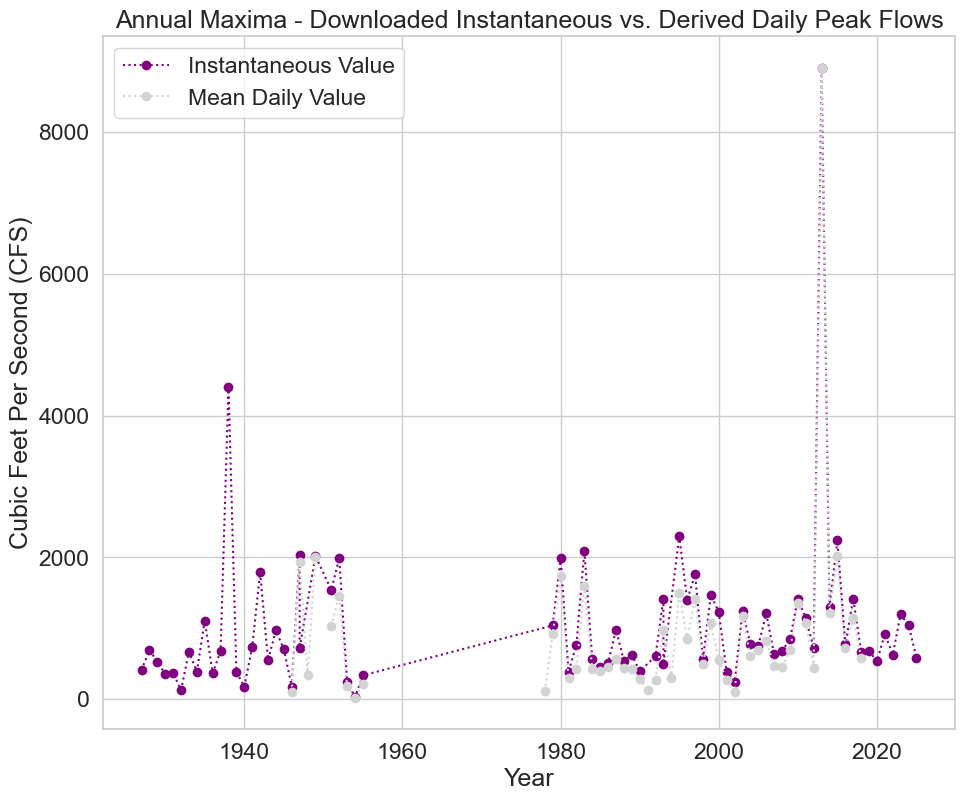

In [108]:
# Plot calculated vs USGS annual max flow values
fig, ax = plt.subplots(figsize=(11, 9))

ax.plot(usgs_annual_max["year"],
        usgs_annual_max["peak_va"],
        color="purple",
        linestyle=':',
        marker='o',
        label="Instantaneous Value")

ax.plot(longmont_discharge_annual_max["year"],
        longmont_discharge_annual_max["discharge"],
        color="lightgrey",
        linestyle=':',
        marker='o', label="Mean Daily Value")
ax.legend()
ax.set_title(
    "Annual Maxima - Downloaded Instantaneous vs. Derived Daily Peak Flows")
ax.set_xlabel("Year")
ax.set_ylabel("Cubic Feet Per Second (CFS)")

plt.show()

In [109]:
# Merge the two pandas dataframes on the year column
usgs_calculated = pd.merge(longmont_discharge_annual_max,
                           usgs_annual_max,
                           left_on="year",
                           right_on="year")

# Subtract usgs values from your calculated values
usgs_calculated["diff"] = usgs_calculated["peak_va"] - \
    usgs_calculated["discharge"]

In [110]:
usgs_calculated.head()

,discharge,flag,year,peak_va,diff
0,99.0,A,1946,178.0,79.0
1,1930.0,A,1947,2040.0,110.0
2,1930.0,A,1947,721.0,-1209.0
3,2010.0,hf.missing,1949,2020.0,10.0
4,1030.0,hf.missing,1951,1540.0,510.0


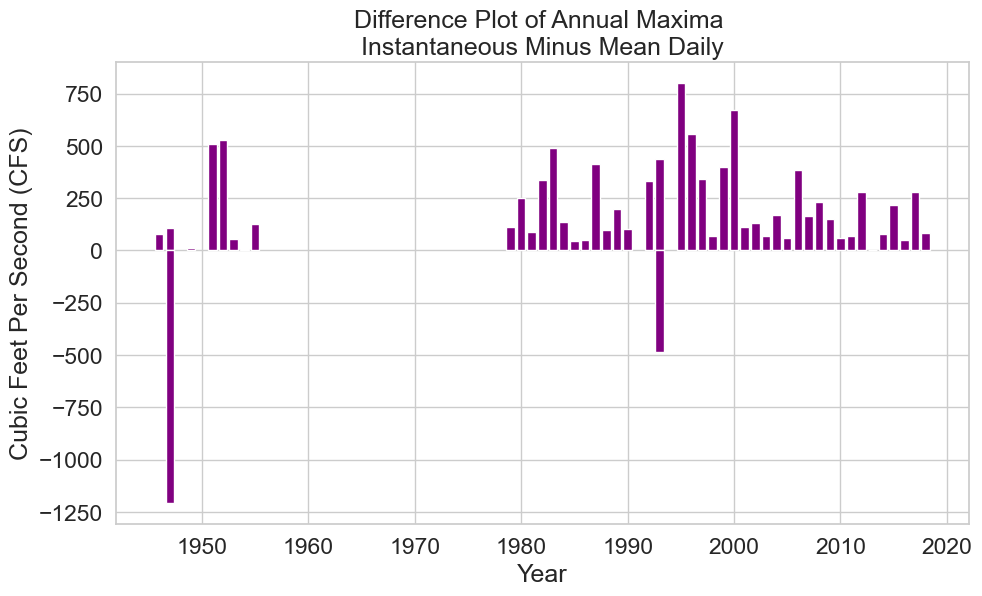

In [111]:
# Plot difference
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(usgs_calculated["year"],
       usgs_calculated["diff"],
      color="purple")

ax.set_title(
    "Difference Plot of Annual Maxima \nInstantaneous Minus Mean Daily")
ax.set_xlabel("Year")
ax.set_ylabel("Cubic Feet Per Second (CFS)")
plt.show()

# Calculate Return  Period

1. Sort your data from smallest to largest.
2. Calculate exceedance probabilities using the equation below where n is length of the record and i is the rank.
3. Calculate the inverse of the exceedance probabilities to determine return period in years.
4. Plot flood magnitudes against return time. It is common to plot these kinds of data on log-linear or log-log axes.
    Probablity=(n−i+1)/(n+1)

In [112]:
#sort values from smallest to largest
longmont_discharge_sorted=longmont_discharge.sort_values(by='discharge')

#count observations
n=longmont_discharge_sorted.shape[0]

#add a numbered column to use to rank each data point
longmont_discharge_sorted.insert(0, 'rank', range(1, 1 + n))

longmont_discharge_sorted["probability"] = (
    (n-longmont_discharge_sorted["rank"] + 1) / (n+1))

longmont_discharge_sorted["return-years"] = (
    1 /longmont_discharge_sorted["probability"])

In [113]:
def calculate_return(df, colname, frequency="annual"):
    '''
    Calculates the exceedance probability and return period in years for a dataset.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The input dataset.
    colname : str
        The column name to sort and calculate probabilities for (e.g., "discharge").
    frequency : str, optional
        The time step of the data. Options are "annual" or "daily". Default is "annual".
    '''
    # Sort data smallest to largest
    sorted_data = df.sort_values(by=colname)
    
    # Count total observations
    n = sorted_data.shape[0]
    
    # Add a numbered column 1 -> n to use in return calculation for rank
    sorted_data.insert(0, 'rank', range(1, 1 + n))
    
    # Calculate exceedance probability using Weibull plotting position formula
    sorted_data["probability"] = (n - sorted_data["rank"] + 1) / (n + 1)
    
    # Calculate return period
    raw_return = 1 / sorted_data["probability"]
    
    # FIX: Adjust the return period to always output in YEARS based on frequency argument
    if frequency.lower() == "daily":
        sorted_data["return-years"] = raw_return / 365.25
    elif frequency.lower() == "annual":
        sorted_data["return-years"] = raw_return
    else:
        raise ValueError("Invalid frequency type. Please choose either 'annual' or 'daily'.")

    return sorted_data# Calculate the same thing using the USGS annual max data
usgs_annual_prob = calculate_return(usgs_annual_max, "peak_va")
usgs_annual_prob.head()

,rank,peak_va,year,probability,return-years
peak_dt,,,,,
1954-01-14,1,26.0,1954,0.986667,1.013514
1932-07-13,2,128.0,1932,0.973333,1.027397
1940-07-03,3,174.0,1940,0.960000,1.041667
1946-07-19,4,178.0,1946,0.946667,1.056338
2002-05-24,5,238.0,2002,0.933333,1.071429


In [114]:
longmont_prob = calculate_return(longmont_discharge, "discharge")

# Because these data are daily,
# divide return period in days by 365 to get a return period in years
longmont_prob["return-years"] = longmont_prob["return-years"] / 365
longmont_prob["probability"] = longmont_prob["probability"] * 365
longmont_prob.tail()

,rank,discharge,flag,year,probability,return-years
datetimeUTC,,,,,,
1991-09-26 00:00:00+00:00,26406,NaN,hf.missing,1991,0.06910,14.471781
1991-09-27 00:00:00+00:00,26407,NaN,hf.missing,1991,0.05528,18.089726
1991-09-28 00:00:00+00:00,26408,NaN,hf.missing,1991,0.04146,24.119635
1991-09-29 00:00:00+00:00,26409,NaN,hf.missing,1991,0.02764,36.179452
1991-09-30 00:00:00+00:00,26410,NaN,hf.missing,1991,0.01382,72.358904


In [115]:
# Calculate the same thing using the USGS annual max data
usgs_annual_prob = calculate_return(usgs_annual_max, "peak_va")
usgs_annual_prob.head()

,rank,peak_va,year,probability,return-years
peak_dt,,,,,
1954-01-14,1,26.0,1954,0.986667,1.013514
1932-07-13,2,128.0,1932,0.973333,1.027397
1940-07-03,3,174.0,1940,0.960000,1.041667
1946-07-19,4,178.0,1946,0.946667,1.056338
2002-05-24,5,238.0,2002,0.933333,1.071429


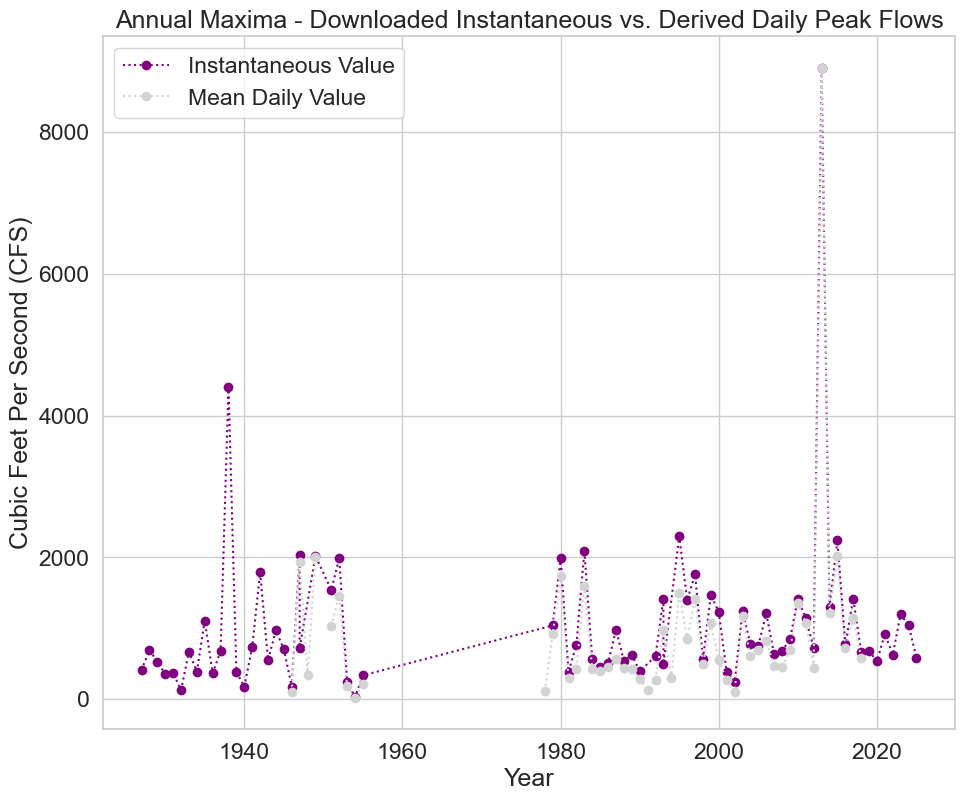

In [119]:
# Plot calculated vs USGS annual max flow values
fig, ax = plt.subplots(figsize=(11, 9))

ax.plot(usgs_annual_max["year"],
        usgs_annual_max["peak_va"],
        color="purple",
        linestyle=':',
        marker='o',
        label="Instantaneous Value")

ax.plot(longmont_discharge_annual_max["year"],
        longmont_discharge_annual_max["discharge"],
        color="lightgrey",
        linestyle=':',
        marker='o', label="Mean Daily Value")
ax.legend()
ax.set_title(
    "Annual Maxima - Downloaded Instantaneous vs. Derived Daily Peak Flows")
ax.set_xlabel("Year")
ax.set_ylabel("Cubic Feet Per Second (CFS)")

plt.show()

In [125]:
print(longmont_prob.columns)

Index(['rank', 'discharge', 'flag', 'year', 'probability', 'return-years'], dtype='str')


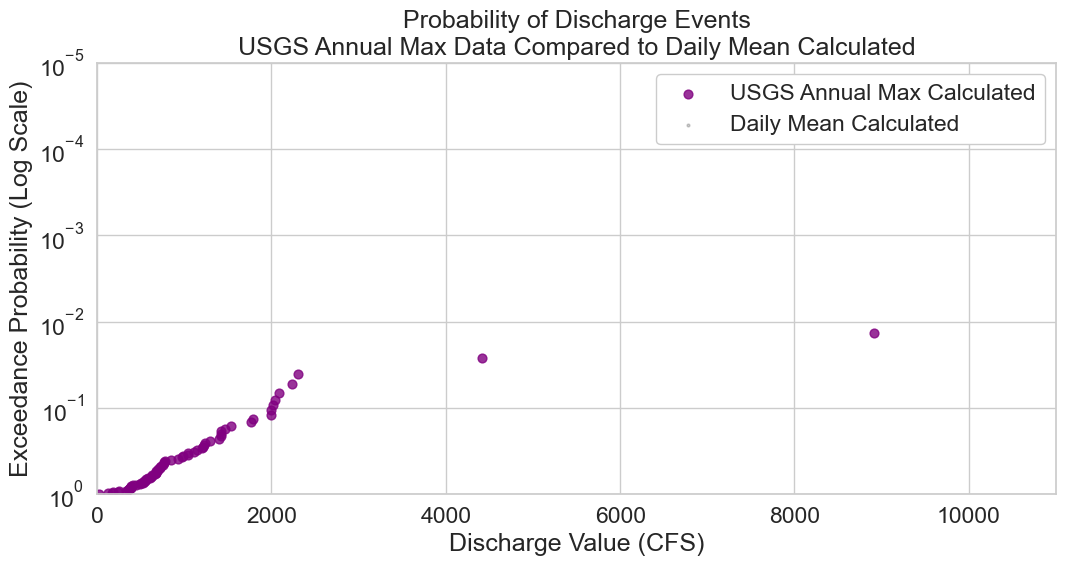

In [124]:
# 1. Initialize a unified canvas
fig, ax = plt.subplots(figsize=(11, 6))

# 2. Plot Layer 1: USGS Annual Max Data (Purple)
ax.scatter(x=usgs_annual_prob["peak_va"],
           y=usgs_annual_prob["probability"],
           color="purple",
           s=40,
           alpha=0.8,
           label="USGS Annual Max Calculated")

# 3. Plot Layer 2: Daily Mean Data (Grey)
ax.scatter(x=longmont_prob["discharge"],
           y=longmont_prob["probability"],
           color="grey",
           s=4,
           alpha=0.4,
           label="Daily Mean Calculated")

# 4. Apply a unified log scale to the Y-axis
ax.set_yscale("log")

# 5. Invert the Y-axis so rare probabilities are at the very top
ax.invert_yaxis()

# 6. FORCE the limits to stretch down to 0.00001 (10^-5) and out to 11,000 CFS
ax.set_ylim(1.0, 0.00001)  
ax.set_xlim(0, 11000)      

# Customization Labels
ax.set_ylabel("Exceedance Probability (Log Scale)")
ax.set_xlabel("Discharge Value (CFS)")
ax.set_title("Probability of Discharge Events\nUSGS Annual Max Data Compared to Daily Mean Calculated")
ax.legend(frameon=True, framealpha=1, loc="upper right")

plt.tight_layout()
plt.show()

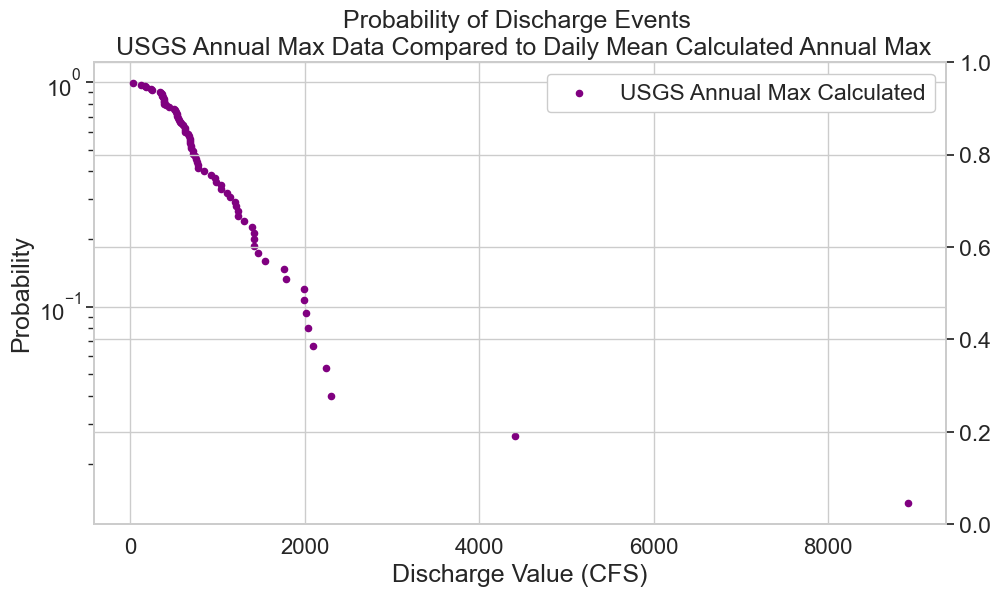

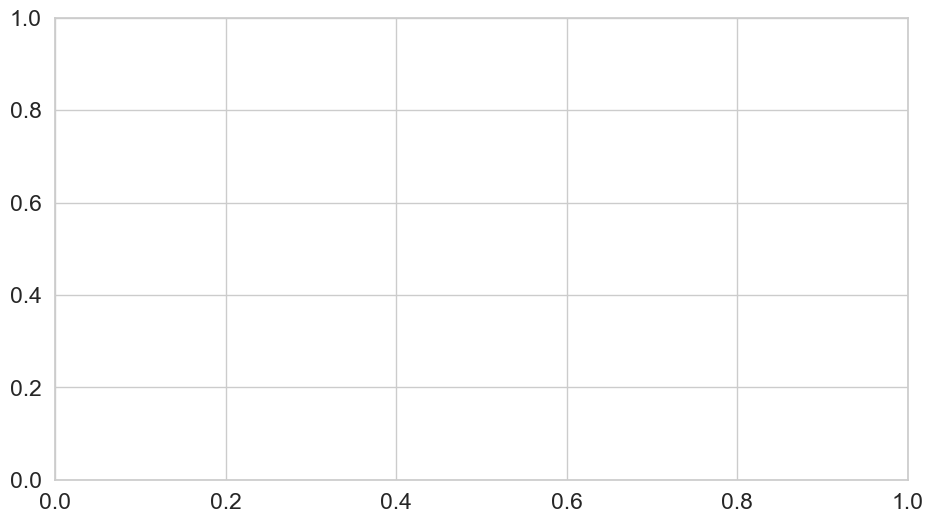

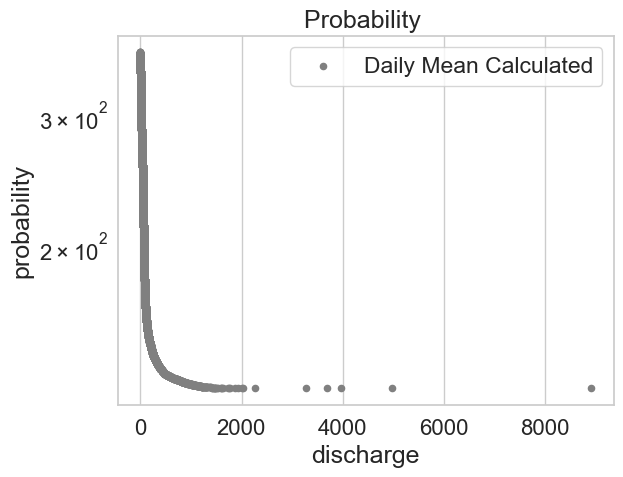

In [123]:
# Compare both datasets
fig, ax = plt.subplots(figsize=(11, 6))
fig, ax2 = plt.subplots(figsize=(11, 6))

ax=usgs_annual_prob.plot.scatter(x="peak_va",
                              y="probability",
                              title="Probability ",
                              ax=ax,
                              color='purple',
                              fontsize=16,
                              logy=True,
                              label="USGS Annual Max Calculated")

ax2 = ax.twinx()
ax2=longmont_prob.plot.scatter(x="discharge",
                           y="probability",
                           title="Probability ",
                          
                           color='grey',
                           fontsize=16,
                           logy=True,
                           label="Daily Mean Calculated")
ax.legend(frameon=True,
          framealpha=1)

ax.set_ylabel("Probability")
ax.set_xlabel("Discharge Value (CFS)")
ax.set_title(
    "Probability of Discharge Events \n USGS Annual Max Data Compared to Daily Mean Calculated Annual Max")

plt.show()

why is Daily Mean Calculated from the longmont_prob not showing values under 10^2?\

In [117]:
longmont_prob['probability'].min()

np.float64(0.013819999242739769)

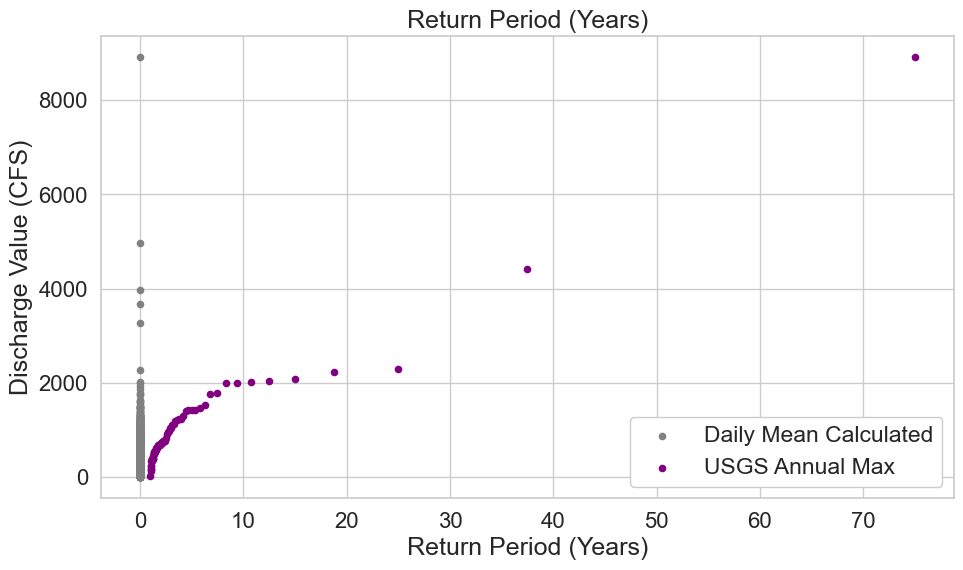

In [118]:
fig, ax = plt.subplots(figsize=(11, 6))

longmont_prob.plot.scatter(y="discharge",
                           x="return-years",
                           title="Return Period (Years)",
                           ax=ax,
                           color='grey',
                           fontsize=16,
                           label="Daily Mean Calculated")

usgs_annual_prob.plot.scatter(y="peak_va",
                              x="return-years",
                              title="Return Period (Years)",
                              ax=ax,
                              color='purple',
                              fontsize=16,
                              label="USGS Annual Max")
ax.legend(frameon=True,
          framealpha=1)

ax.set_xlabel("Return Period (Years)")
ax.set_ylabel("Discharge Value (CFS)")

plt.show()